# Price Elasticity with PyMC

## Import packages

In [211]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import graphviz
import arviz as az
import seaborn as sns
import pymc as pm
from IPython.display import display

In [183]:
# impport datasets
data = pd.read_csv('data/synthetic_dataset.csv')
product_elasticities_df = pd.read_csv('data/product_elasticities_df.csv')

## EDA

### Price vs. elasticity

In [60]:
rng = np.random.default_rng(seed=42)
### Price vs. Quantity - plot 6 products randomly selected from each state * brand combination
brand_choice = list(rng.choice(product_elasticities_df['product'].unique(),6, replace=False))
state_choice = product_elasticities_df['state'].unique()
product_list_choice = [i +' ('+ j + ')' for i in brand_choice for j in rng.choice(state_choice,1, replace=False)]

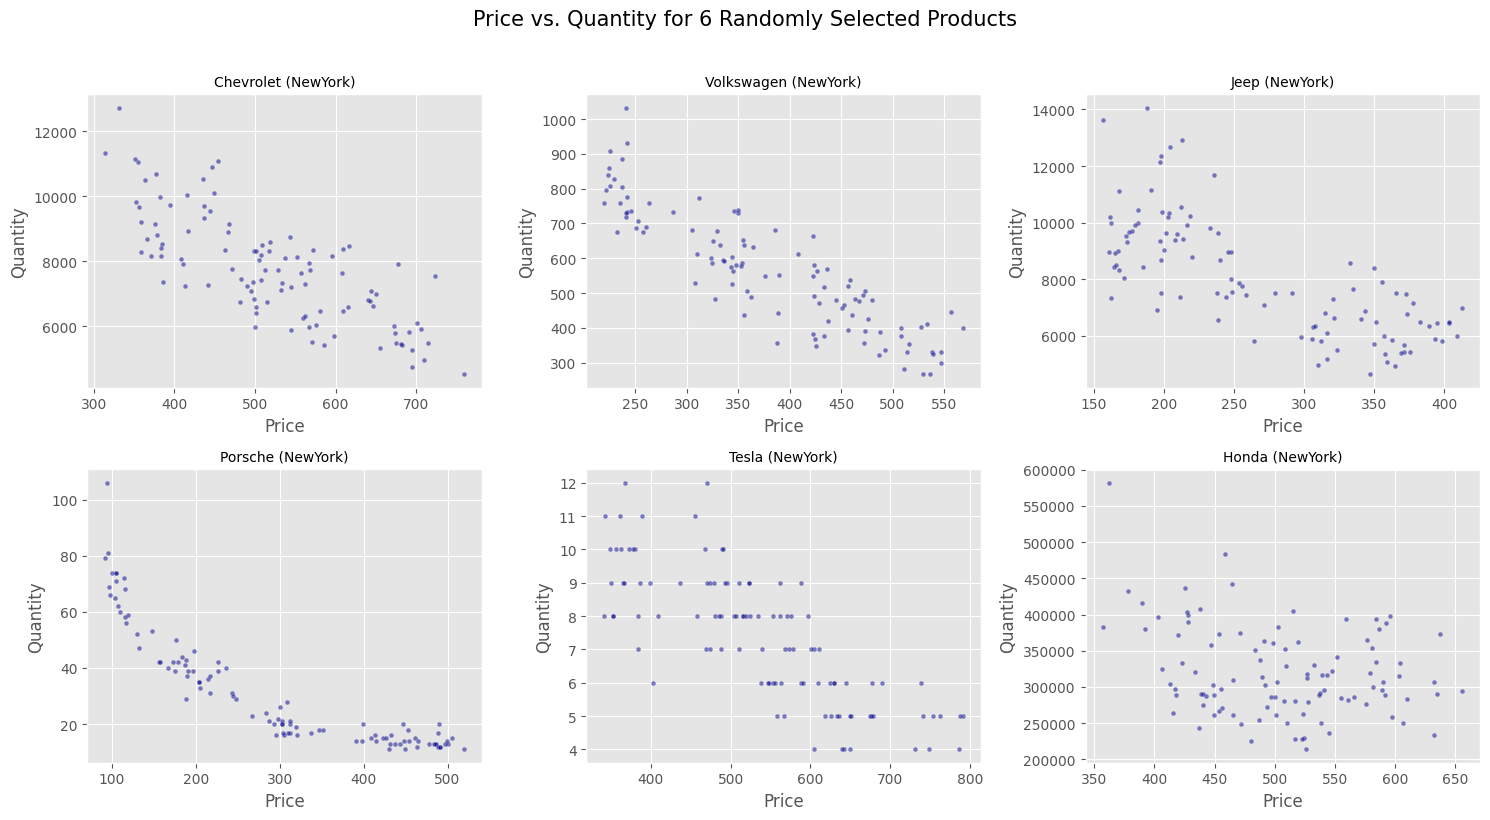

In [61]:
# scatter plot

plt.style.use('ggplot')
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
for ax, product in zip(axes.flatten(), product_list_choice):
  sns.scatterplot(
  data = data.loc[data['product_id'] == product],
  x = 'price',
  y = 'quantity',
  ax = ax,
  alpha = 0.5,
  s=12,
  color = 'darkblue'
  )
  ax.set_xlabel('Price')
  ax.set_ylabel('Quantity')
  ax.set_title(product, fontsize=10)
plt.suptitle('Price vs. Quantity for 6 Randomly Selected Products', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/EDA/price_vs_quantity.png', bbox_inches='tight')

### Own elasticities vs. cross elasticities

In [126]:
# transform product elasticities dataframe to long format for plotting
product_elasticities_long_df = product_elasticities_df.melt(
  id_vars = ['category','state','product','elasticity','intercept'],
  var_name = 'paired_product',
  value_name = 'cross_elasticity'
)
# remove na
product_elasticities_long_df.dropna(axis=0, how='any', inplace=True)

# remove state from the paired product names
words_to_remove = [' (Florida)', ' (NewYork)']
for word in words_to_remove:
    product_elasticities_long_df['paired_product'] = product_elasticities_long_df['paired_product'].str.replace(word, '')
# save dataframe
product_elasticities_long_df.to_csv('data/product_elasticities_long_df.csv')

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_56668/3711903008.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


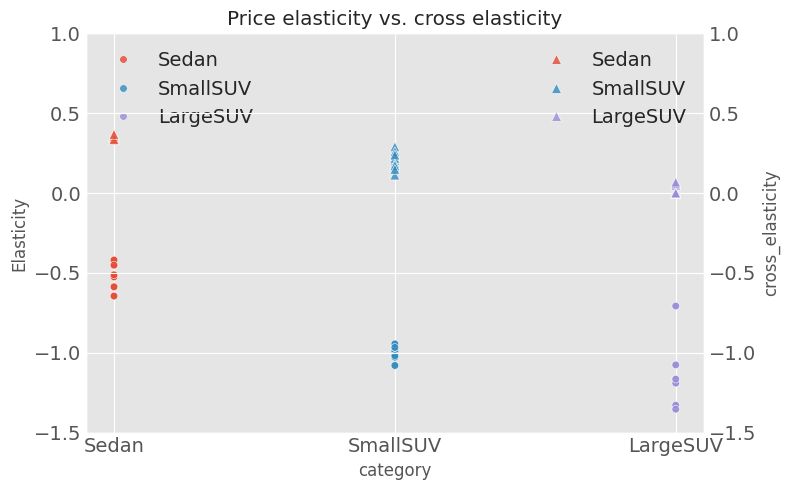

In [288]:
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=product_elasticities_long_df,
    x='category',
    y='elasticity',
    hue='category',
    marker='o',
#    palette='Set1',
    s=30,
    alpha=0.8,
    ax = ax
)
ax.set_ylim(-1.5, 1)
ax.set_ylabel('Elasticity')
ax.legend(loc='upper left')
ax2 = ax.twinx()
sns.scatterplot(
    data=product_elasticities_long_df,
    x='category',
    y='cross_elasticity',
    hue='category',
    marker='^',
#    palette='Set1',
    s=50,
    alpha=0.8,
    ax = ax2
)
ax2.set_ylim(-1.5, 1)
ax2.legend(loc='upper right')
plt.title('Price elasticity vs. cross elasticity')
plt.tight_layout()
#plt.savefig('images/EDA/elasticity_crosselasticity.png')

## Model

### No pooling
Each product has its own elasticity, and estimated independently

In [186]:
# create a mapping of product_id to an index for use in the model
product_ids = sorted(data["product_id"].unique())
product_idx_map = {s: i for i, s in enumerate(product_ids)}
obs_product_idx = data["product_id"].map(product_idx_map).values

In [ ]:


# Label the dimension of model variables with the name of the coordinate, which is "product_id" in this case.
coords = {
    'product_id': data['product_id'].unique()
}
# Build PyMC no pooling model
with pm.Model(coords=coords) as no_pooling_model:
    # Intercept to baseline demand
    alpha = pm.Normal("alpha", mu=10, sigma=2.0, dims="product_id")
    # Prior of overall elasticity mean across all products
    mu_elasticity = pm.Normal('mu_elasticity', mu=-1, sigma=0.5, dims='product_id')

    # Additive seasonality effect on elasticity mean
    beta_season = pm.Normal('beta_season', mu=0, sigma=0.5) # Can be positive or negative

    # Add standard deviation for the elasticity distributions
    sigma = pm.HalfNormal('sigma', sigma=0.5)

    # Define the expected log-quantity
    mu = (
        alpha[obs_product_idx] # use index due to tensor indexing requiring integers
        + mu_elasticity[obs_product_idx] * data["log_price"].values
        + beta_season * data["seasonality"].values
        )

    # Define the Bayesian model, connecting model's predictions to the actual data
    pm.Normal("obs", mu=mu, sigma=sigma, observed=data["log_quantity"].values)

    # Run MCMC sampling to approximate the posterior distribution
    trace_no_pooling = pm.sample(
            1000, # sample size
            tune=1000,  # tune-steps
            chains=2, # 2 independent chains
            cores=1,
            random_seed=42, progressbar=True,
            target_accept=0.9, # smaller step
        )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, mu_elasticity, beta_season, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 86 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


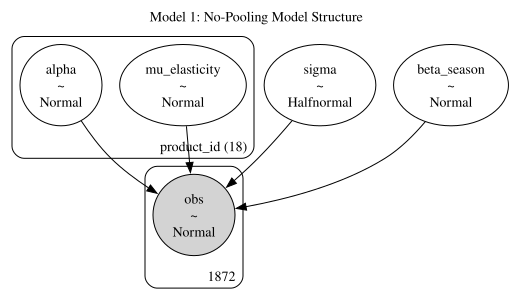

In [214]:
# Display PyMC chart for no-pooling model
pychart_no_pooling = pm.model_to_graphviz(
  model=no_pooling_model,
  graph_attr={
        "label": "Model 1: No-Pooling Model Structure",
        "labelloc": "top"
  }
  )
pychart_no_pooling.render(
  filename='images/model/pychart_no_pooling',
  format='png',
  cleanup=True
)
display(pychart_no_pooling)

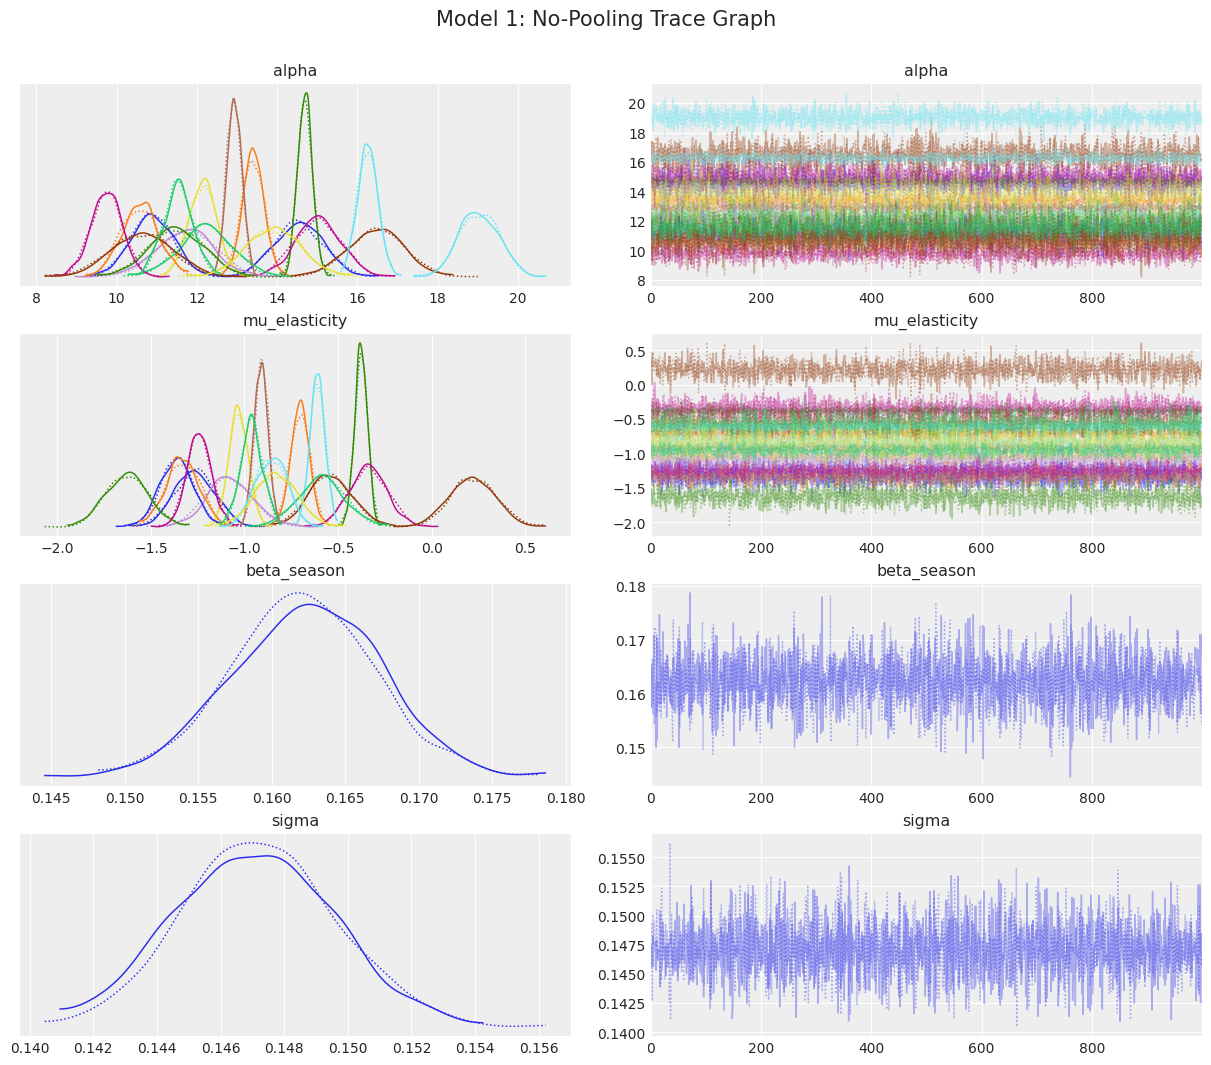

In [220]:
# Generates visual diagnostic subplots for every sampled parameter
az.style.use("arviz-darkgrid")
axes = az.plot_trace(
    data=trace_no_pooling,
    figsize=(12, 10)
)
plt.suptitle('Model 1: No-Pooling Trace Graph', fontsize=15, y=1.05)
plt.savefig('images/model/trace_no_pooling.png')

In [246]:
# Compare true elasticity vs. no-pooling estimated elasticities
no_pooling_output = []
for i in data['product_id'].unique():
  product = i
  true_elasticity = data.loc[data['product_id']==i]['elasticity'].mean()
  post_elasticity = trace_no_pooling.posterior.sel(product_id=i)['mu_elasticity'].values.flatten().mean()
  post_elasticity_lower_bound = np.percentile(trace_no_pooling.posterior.sel(product_id=i)['mu_elasticity'].values, 2.5)
  post_elasticity_higher_bound = np.percentile(trace_no_pooling.posterior.sel(product_id=i)['mu_elasticity'].values, 97.5)

  no_pooling_output.append({
    "product": i,
    "true_elasticity": true_elasticity,
    "post_elasticity": post_elasticity,
    "post_elasticity_lower_bound": post_elasticity_lower_bound,
    "post_elasticity_higher_bound": post_elasticity_higher_bound
    })
no_pooling_output = pd.DataFrame(no_pooling_output)

In [262]:
no_pooling_output

,product,true_elasticity,post_elasticity,post_elasticity_lower_bound,post_elasticity_higher_bound
0,Honda (Florida),-0.419528,-1.266881,-1.470389,-1.062607
1,Honda (NewYork),-0.524955,-0.703225,-0.802861,-0.604688
2,Hyundai (Florida),-0.645104,-0.377535,-0.446928,-0.311303
3,Hyundai (NewYork),-0.587216,-0.338964,-0.537444,-0.136483
4,Toyota (Florida),-0.451680,-0.542284,-0.764779,-0.312279
5,Toyota (NewYork),-0.512060,-0.609973,-0.688055,-0.533844
6,Volkswagen (Florida),-0.990095,-1.031479,-1.136848,-0.929608
7,Volkswagen (NewYork),-1.079874,-0.586336,-0.823062,-0.346294
8,Mazda (Florida),-0.944687,-1.080200,-1.320163,-0.827218
9,Mazda (NewYork),-1.018232,-0.910605,-0.981784,-0.838005


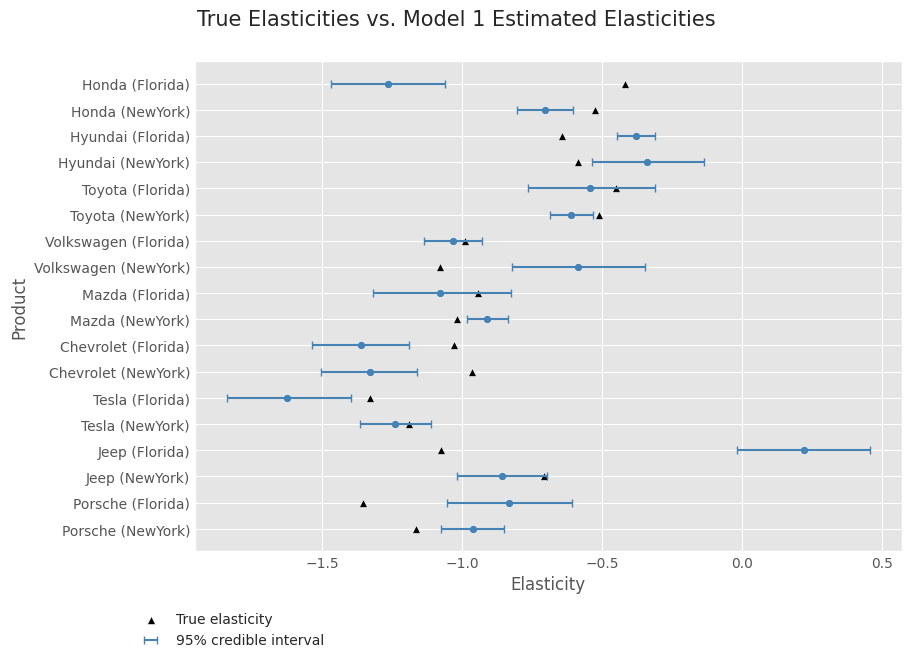

In [ ]:
# visualize true elasticity vs. no-pooling estimated elasticities
# mean true elasticity
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(9,6))
sns.scatterplot(
  no_pooling_output,
  x = 'true_elasticity',
  y = 'product',
  marker='^',
  s=35,
  color='black',
  ax = ax,
  label='True elasticity'
)
# mean posterior elasticity
sns.scatterplot(
  no_pooling_output,
  x = 'post_elasticity',
  y = 'product',
  marker='o',
  s=35,
  color='steelblue',
  ax = ax
)
# Posterior credible interval
ax.errorbar(
    no_pooling_output['post_elasticity'],
    no_pooling_output['product'],
    xerr=[
        no_pooling_output['post_elasticity'] - no_pooling_output['post_elasticity_lower_bound'],
        no_pooling_output['post_elasticity_higher_bound'] - no_pooling_output['post_elasticity']
    ],
    fmt='none',
    color='steelblue',
    capsize=3,
    label="95% credible interval"
)
ax.set_xlabel('Elasticity')
ax.set_ylabel('Product')
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.legend(bbox_to_anchor=(0.2, -0.1), fontsize=10)
#ax.set_yticklabels(no_pooling_output['product'],fontsize=10)
plt.suptitle('True Elasticities vs. Model 1 Estimated Elasticities', fontsize=15, y=1.08)
plt.savefig('images/model/elasticity_chart_no_pooling.png', bbox_inches='tight')

### Model 2 - Hierarchical (partial pooling)
Each product has its own elasticity, but estimated including the elasticities of their category and the state

In [ ]:
# create category and state mappings to indices in the model
cat_names = sorted(data["category"].unique())
state_names = sorted(data["state"].unique())
cat_idx_map = {c: i for i, c in enumerate(cat_names)}
state_idx_map = {r: i for i, r in enumerate(state_names)}

product_to_cat = np.array([
  cat_idx_map[data.loc[data['product_id'] == s, 'category'].values[0]]
  for s in product_ids
], dtype=int)
product_to_state = np.array([
  state_idx_map[data.loc[data['product_id'] == s, 'state'].values[0]]
  for s in product_ids
  ], dtype=int)

In [406]:
# Label the dimension of model variables with the name of the coordinate, which are "product_id", "category" and "state" in this case.

coords ={
  "product_id": data['product_id'].unique(),
  "category": data['category'].unique(),
  "state": data['state'].unique()
}

In [ ]:
# Build PyMC partial pooling model
with pm.Model(coords=coords) as partial_pooling_model:
    # Global hyperpriors
    mu_global = pm.Normal("mu_global", mu=-1.0, sigma=0.5)
    sigma_cat = pm.HalfNormal("sigma_cat", sigma=0.5)

    # Non-centered Category Elasticity
    cat_offset = pm.Normal("cat_offset", mu=0.0, sigma=1.0, dims="category")
    mu_cat_elasticity = pm.Deterministic(
        "mu_cat", mu_global + cat_offset * sigma_cat, dims="category"
    )

    # State shifts
    state_shift = pm.Normal("state_shift", mu=0.0, sigma=0.15, dims="state")

    # Non-centered Product-level Elasticity
    sigma_product = pm.HalfNormal("sigma_product", sigma=0.3)
    product_offset = pm.Normal("product_offset", mu=0.0, sigma=1.0, dims="product_id")

    elasticity_cat = (
        mu_cat_elasticity[product_to_cat]
        + state_shift[product_to_state]
        + sigma_product * product_offset
    )
    elasticity_product = pm.Deterministic("elasticity_product", elasticity_cat, dims="product_id")

    # Intercepts & Likelihood
    alpha_product = pm.Normal("alpha_product", mu=6.0, sigma=2.0, dims="product_id")
    beta_season = pm.Normal("beta_season", mu=0.0, sigma=0.5)
    sigma = pm.HalfNormal("sigma", sigma=0.5)

    mu = (
        alpha_product[obs_product_idx]
        + elasticity_product[obs_product_idx] * data["log_price"].values
        + beta_season * data["seasonality"].values
    )

    pm.Normal("obs", mu=mu, sigma=sigma, observed=data["log_quantity"].values)

    trace_hier = pm.sample(
        1000, tune=3000, chains=4, cores=2,
        random_seed=42, progressbar=True, target_accept=0.95,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [mu_global, sigma_cat, cat_offset, state_shift, sigma_product, product_offset, alpha_product, beta_season, sigma]


Output()

Sampling 4 chains for 3_000 tune and 1_000 draw iterations (12_000 + 4_000 draws total) took 725 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


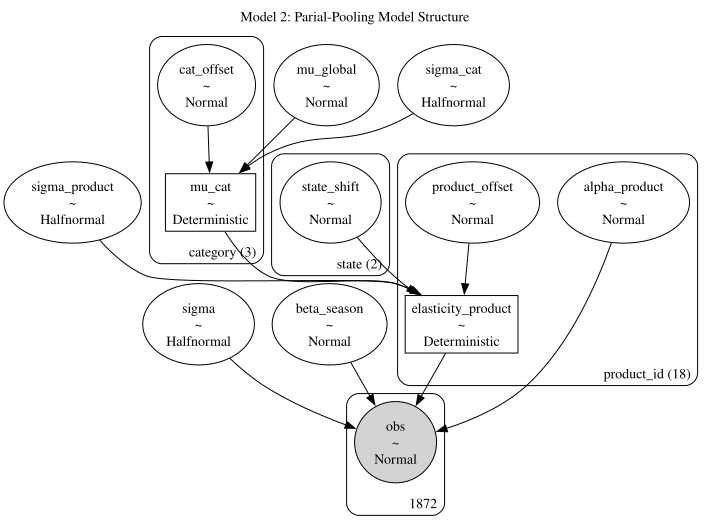

In [ ]:
# Display PyMC graph for partial pooling model
pychart_partial_pooling = pm.model_to_graphviz(
  model = partial_pooling_model,
  graph_attr={
    'label': "Model 2: Parial-Pooling Model Structure",
    'labelloc': "top"
  }
)
pychart_partial_pooling.render(
  filename='images/model/pychart_partial_pooling.png',
  format='png',
  cleanup=True
)
display(pychart_partial_pooling)

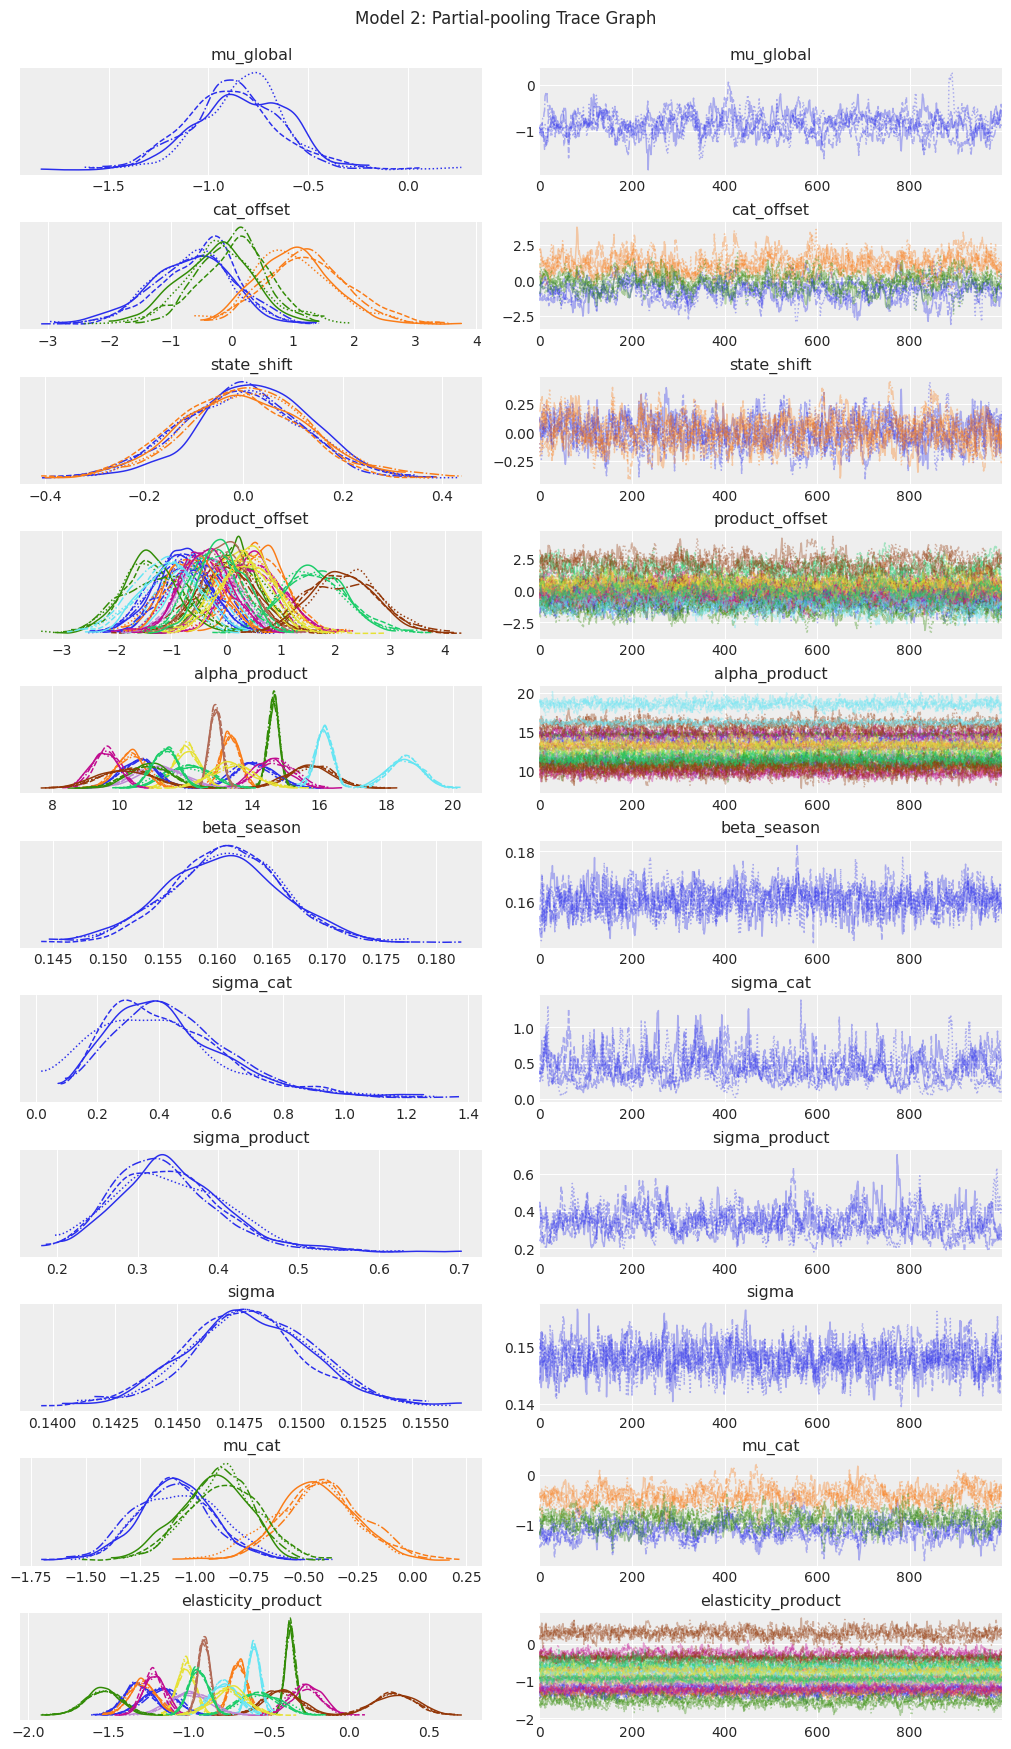

In [410]:
# Visualize the trace
az.style.use('arviz-darkgrid')
trace_plot = az.plot_trace(
  data = trace_hier,
  figsize=(10,17)
)
plt.suptitle('Model 2: Partial-pooling Trace Graph', y=1.02)
plt.savefig('images/model/trace_partial_pooling.png', bbox_inches='tight')


In [413]:
# Compare true elasticity and the hierarchical pooling estimated elasticity
partial_pooling_output = []
for i in data['product_id'].unique():
  product_ = i
  true_elasticity = data.loc[data['product_id']==i, 'elasticity'].mean()
  post_elasticity = trace_hier.posterior.sel(product_id=i)['elasticity_product'].values.mean()
  post_elasticity_lower_bound = np.percentile(trace_hier.posterior.sel(product_id=i)['elasticity_product'].values, 2.5)
  post_elasticity_upper_bound = np.percentile(trace_hier.posterior.sel(product_id=i)['elasticity_product'].values, 97.5)
  partial_pooling_output.append({
    'product': i,
    "true_elasticity": true_elasticity,
    "post_elasticity": post_elasticity,
    "post_elasticity_upper_bound": post_elasticity_upper_bound,
    "post_elasticity_lower_bound": post_elasticity_lower_bound
  })
partial_pooling_output= pd.DataFrame(partial_pooling_output)


In [414]:
partial_pooling_output

,product,true_elasticity,post_elasticity,post_elasticity_upper_bound,post_elasticity_lower_bound
0,Honda (Florida),-0.419528,-1.179564,-0.975018,-1.391981
1,Honda (NewYork),-0.524955,-0.690714,-0.589489,-0.793949
2,Hyundai (Florida),-0.645104,-0.366952,-0.301114,-0.430528
3,Hyundai (NewYork),-0.587216,-0.271884,-0.083329,-0.456767
4,Toyota (Florida),-0.451680,-0.424636,-0.198226,-0.650835
5,Toyota (NewYork),-0.512060,-0.592374,-0.511038,-0.667085
6,Volkswagen (Florida),-0.990095,-1.014015,-0.911330,-1.118312
7,Volkswagen (NewYork),-1.079874,-0.558077,-0.314222,-0.802862
8,Mazda (Florida),-0.944687,-0.988732,-0.748470,-1.232016
9,Mazda (NewYork),-1.018232,-0.904078,-0.835154,-0.976160


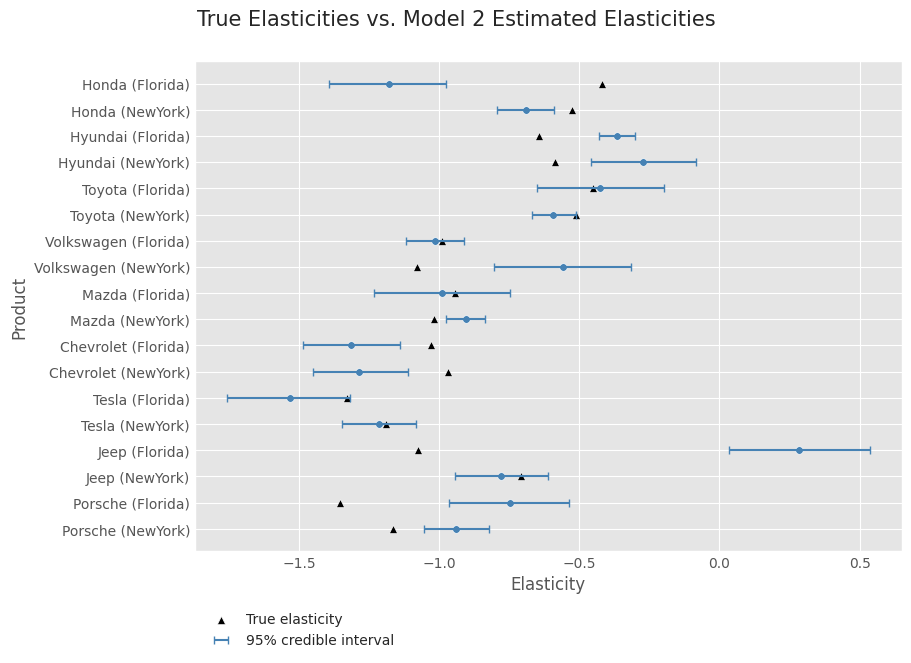

In [415]:
# visualize true elasticity vs. partial-pooling estimated elasticities
# mean true elasticity
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(9,6))
sns.scatterplot(
  data = partial_pooling_output,
  x = 'true_elasticity',
  y = 'product',
  color='black',
  marker='^',
  s=35,
  ax = ax,
  label = 'True elasticity'
)
# posterior elasticity
sns.scatterplot(
  data = partial_pooling_output,
  x = 'post_elasticity',
  y = 'product',
  color='steelblue',
  marker='o',
  s=30,
  ax = ax
)
# posterior elasticity with 95% CI
ax.errorbar(
  x = partial_pooling_output['post_elasticity'],
  y = partial_pooling_output['product'],
  xerr=[
          partial_pooling_output['post_elasticity'] - partial_pooling_output['post_elasticity_lower_bound'],
          partial_pooling_output['post_elasticity_upper_bound'] - partial_pooling_output['post_elasticity']
      ],
      fmt='none',
      color='steelblue',
      capsize=3,
  label="95% credible interval"
)
ax.set_ylabel('Product')
ax.set_xlabel('Elasticity')
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
ax.legend(bbox_to_anchor = (0.3, - 0.1), fontsize=10)
plt.suptitle('True Elasticities vs. Model 2 Estimated Elasticities', fontsize=15, y=1.08)
plt.savefig('images/model/elasticity_chart_partial_pooling.png', bbox_inches='tight')